Imports & Load

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('twitchdata-update.csv')  # load dataset

print(df.info())  # show structure
df.head()  # preview data

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Channel               1000 non-null   str  
 1   Watch time(Minutes)   1000 non-null   int64
 2   Stream time(minutes)  1000 non-null   int64
 3   Peak viewers          1000 non-null   int64
 4   Average viewers       1000 non-null   int64
 5   Followers             1000 non-null   int64
 6   Followers gained      1000 non-null   int64
 7   Views gained          1000 non-null   int64
 8   Partnered             1000 non-null   bool 
 9   Mature                1000 non-null   bool 
 10  Language              1000 non-null   str  
dtypes: bool(2), int64(7), str(2)
memory usage: 72.4 KB
None


,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English


Missing values

In [4]:
# Check for missing data
print(df.isnull().sum())

Channel                 0
Watch time(Minutes)     0
Stream time(minutes)    0
Peak viewers            0
Average viewers         0
Followers               0
Followers gained        0
Views gained            0
Partnered               0
Mature                  0
Language                0
dtype: int64


Column groups

In [5]:
# define column types
numerical_cols = ['Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers',
                  'Average viewers', 'Followers', 'Followers gained', 'Views gained']
categorical_cols = ['Partnered', 'Mature', 'Language']

Summary stats

In [6]:
# min, max, mean, median, outliers per column
for col in numerical_cols:
    vals = df[col]
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    print(f"{col} -")
    print(f"  Min:      {vals.min():,.0f}")
    print(f"  Max:      {vals.max():,.0f}")
    print(f"  Mean:     {vals.mean():,.1f}")
    print(f"  Median:   {vals.median():,.0f}")
    print(f"  Outliers: {len(outliers)}")
    print()

Watch time(Minutes) -
  Min:      122,192,850
  Max:      6,196,161,750
  Mean:     418,427,930.1
  Median:   234,990,788
  Outliers: 107

Stream time(minutes) -
  Min:      3,465
  Max:      521,445
  Mean:     120,515.2
  Median:   108,240
  Outliers: 48

Peak viewers -
  Min:      496
  Max:      639,375
  Mean:     37,065.1
  Median:   16,676
  Outliers: 113

Average viewers -
  Min:      235
  Max:      147,643
  Mean:     4,781.0
  Median:   2,425
  Outliers: 100

Followers -
  Min:      3,660
  Max:      8,938,903
  Mean:     570,054.1
  Median:   318,063
  Outliers: 89

Followers gained -
  Min:      -15,772
  Max:      3,966,525
  Mean:     205,518.5
  Median:   98,352
  Outliers: 90

Views gained -
  Min:      175,788
  Max:      670,137,548
  Mean:     11,668,165.6
  Median:   6,456,324
  Outliers: 91



Numerical histograms

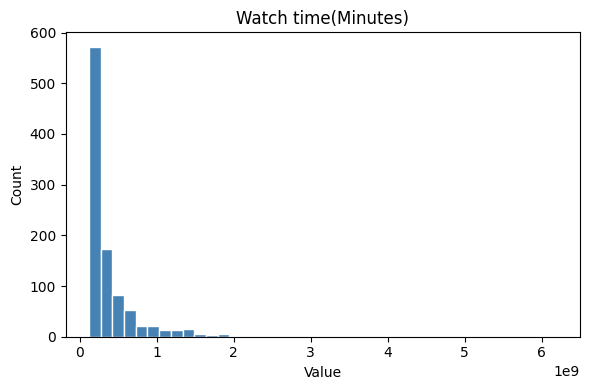

Distribution of 'Watch time(Minutes)'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



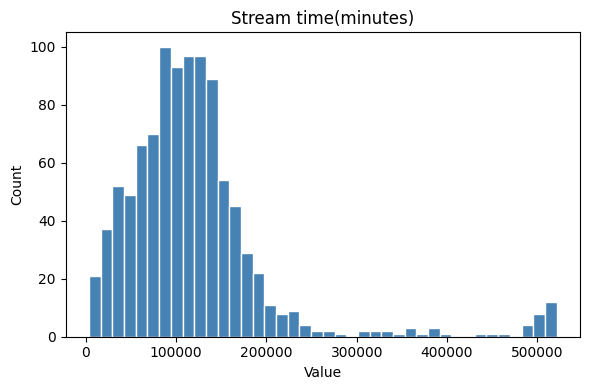

Distribution of 'Stream time(minutes)'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



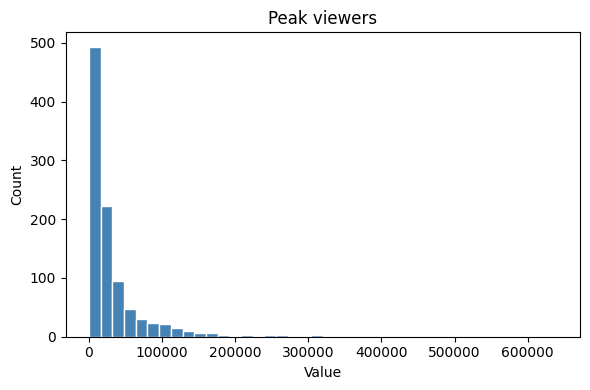

Distribution of 'Peak viewers'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



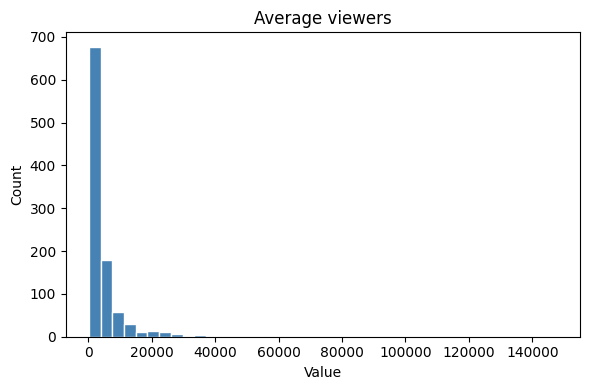

Distribution of 'Average viewers'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



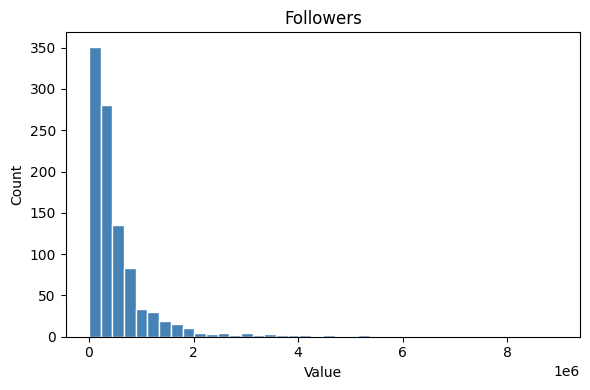

Distribution of 'Followers'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



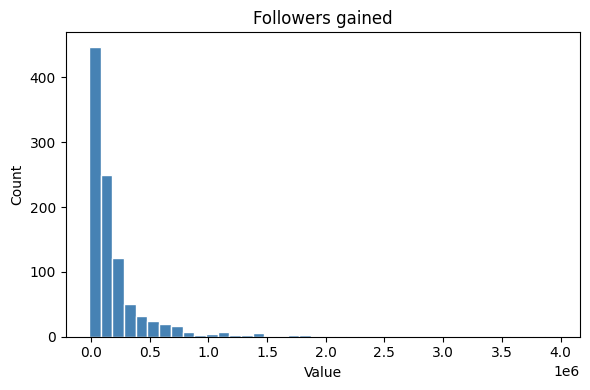

Distribution of 'Followers gained'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



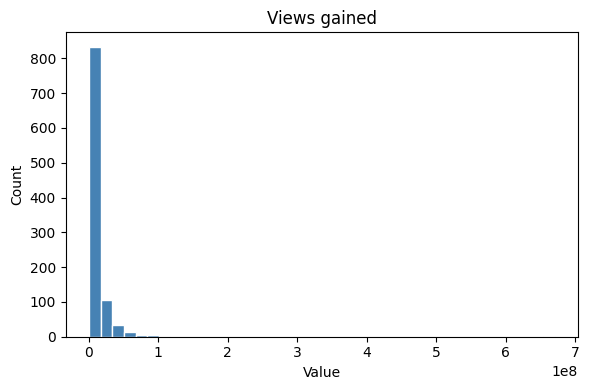

Distribution of 'Views gained'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.



In [7]:
# histogram for each numerical variable
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(f"Distribution of '{col}'. Most streamers have low values with a few very large outliers on the right — typical for popularity data.")
    print()

Categorical bar charts

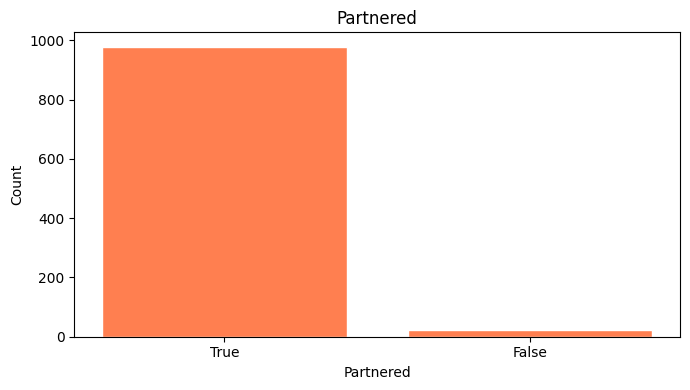

Frequency of each category in 'Partnered'. Shows how the dataset is distributed across groups.



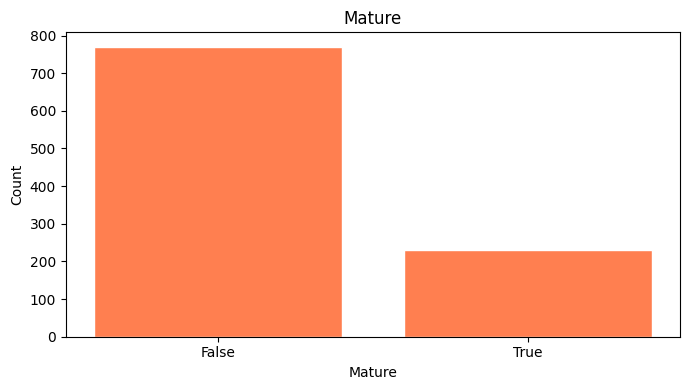

Frequency of each category in 'Mature'. Shows how the dataset is distributed across groups.



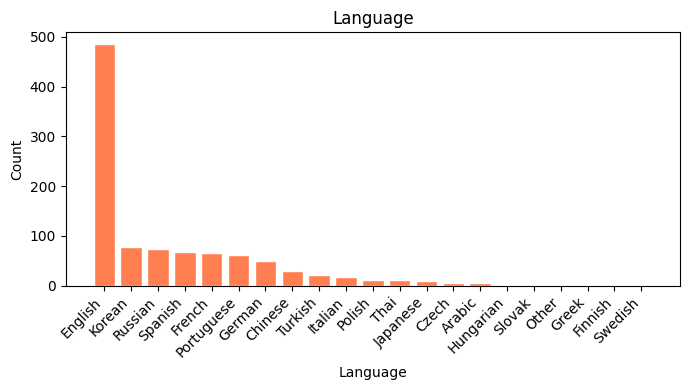

Frequency of each category in 'Language'. Shows how the dataset is distributed across groups.



In [8]:
# bar chart for each categorical variable
for col in categorical_cols:
    counts = df[col].value_counts()
    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values, color='coral', edgecolor='white')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    if col == 'Language':
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(f"Frequency of each category in '{col}'. Shows how the dataset is distributed across groups.")
    print()

Side-by-side box plot

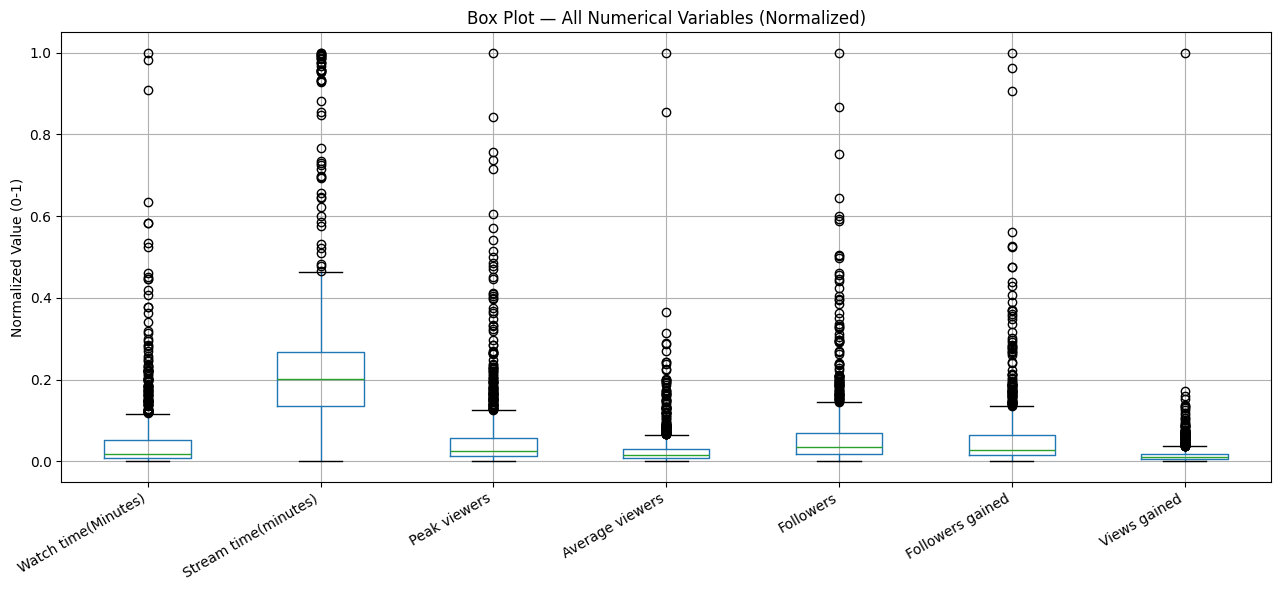

All numerical variables shown side by side on a 0-1 scale. The box shows the middle 50% of the data, the line is the median, and the dots are outliers. Almost every variable has many high-end outliers.


In [9]:
# normalize so all variables fit on same scale
df_scaled = (df[numerical_cols] - df[numerical_cols].min()) / (df[numerical_cols].max() - df[numerical_cols].min())

plt.figure(figsize=(13, 6))
df_scaled.boxplot()
plt.title('Box Plot — All Numerical Variables (Normalized)')
plt.ylabel('Normalized Value (0-1)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print("All numerical variables shown side by side on a 0-1 scale. The box shows the middle 50% of the data, the line is the median, and the dots are outliers. Almost every variable has many high-end outliers.")

Pairwise scatter matrix

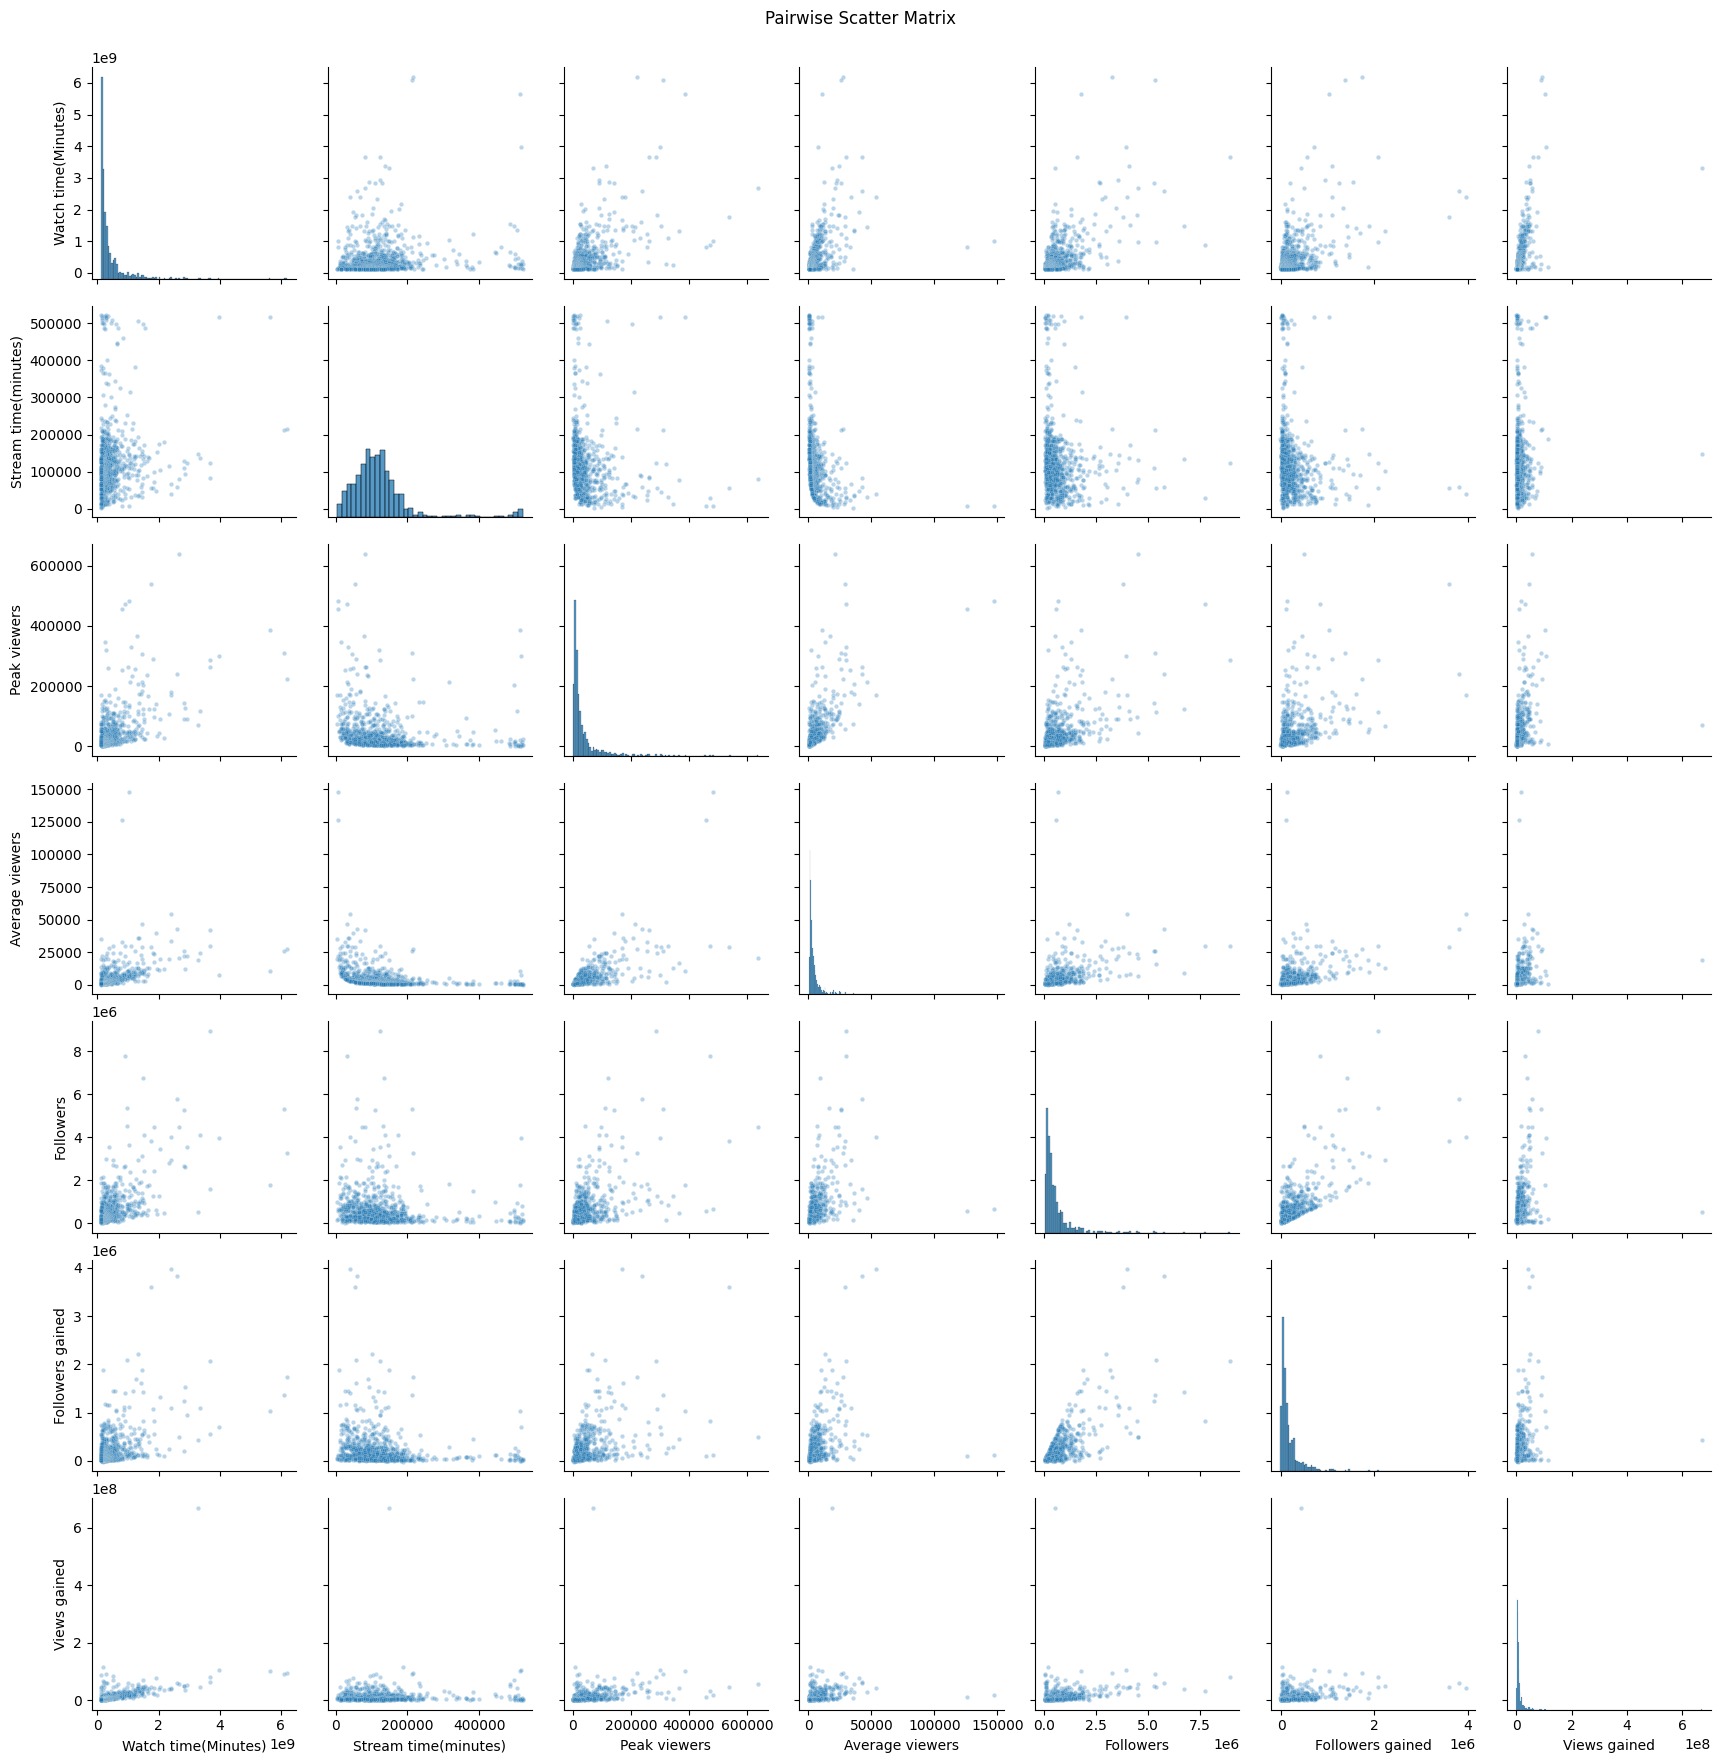

Each plot shows the relationship between two numerical variables. Diagonal shows the distribution of each variable. Strong diagonal patterns mean high correlation — visible between followers, watch time, and views gained.


In [10]:
# scatter matrix for numerical variables only
sns.pairplot(df[numerical_cols], plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairwise Scatter Matrix', y=1.01)
plt.show()
print("Each plot shows the relationship between two numerical variables. Diagonal shows the distribution of each variable. Strong diagonal patterns mean high correlation — visible between followers, watch time, and views gained.")

Categorical vs Categorical: heatmap

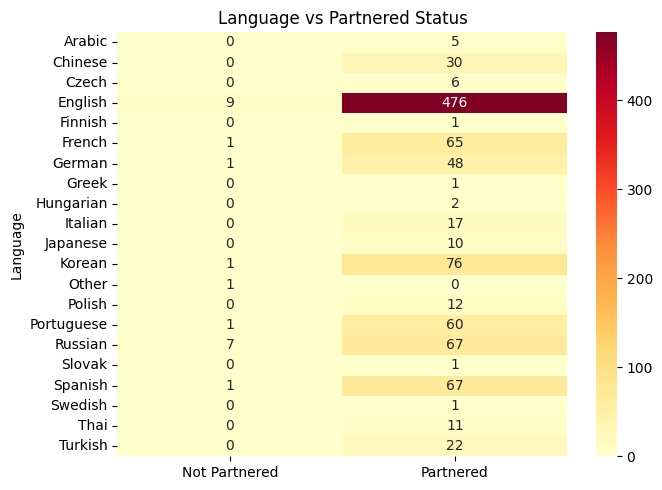

Heatmap of Language vs Partnered status. Each cell shows how many streamers fall in that combination. English partnered streamers make up the largest group by far.


In [11]:
# heatmap shows overlap between two categorical variables
ct = pd.crosstab(df['Language'], df['Partnered'])
ct.columns = ['Not Partnered', 'Partnered']

plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Language vs Partnered Status')
plt.tight_layout()
plt.show()
print("Heatmap of Language vs Partnered status. Each cell shows how many streamers fall in that combination. English partnered streamers make up the largest group by far.")

Categorical vs Categorical: grouped bar

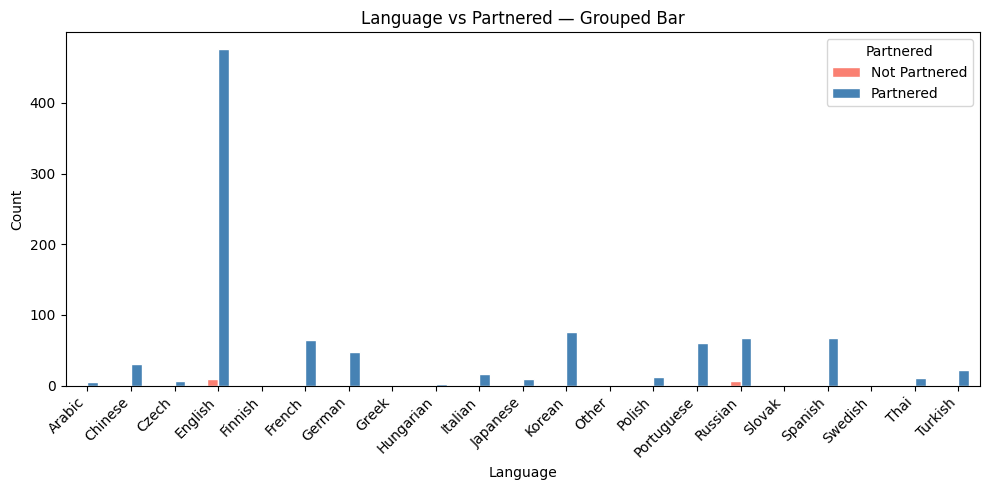

Same data as the heatmap but as a grouped bar chart. Easier to compare counts across languages. Most languages have more partnered than non-partnered streamers in the top 1000.


In [12]:
# grouped bar is another way to compare two categorical variables
ct.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='white', figsize=(10, 5))
plt.title('Language vs Partnered — Grouped Bar')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Partnered')
plt.tight_layout()
plt.show()
print("Same data as the heatmap but as a grouped bar chart. Easier to compare counts across languages. Most languages have more partnered than non-partnered streamers in the top 1000.")

Categorical vs Numerical: box plot

C:\Users\sansk\AppData\Local\Temp\ipykernel_25224\3459532966.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Partnered', y='Average viewers', data=df, palette=['salmon', 'steelblue'])


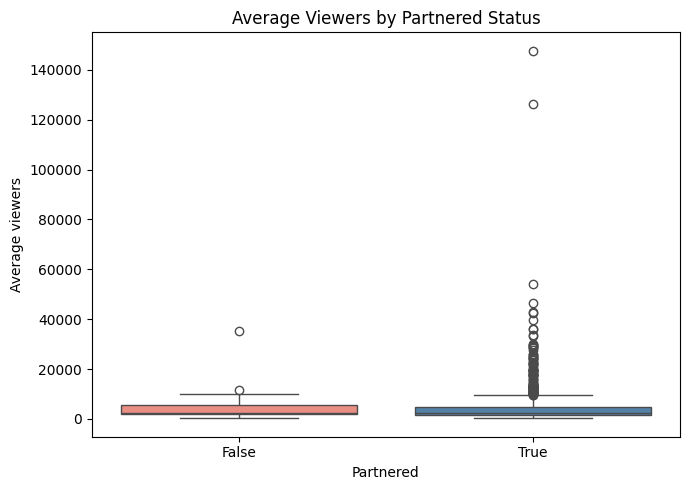

Compares average viewers between partnered and non-partnered streamers. Partnered streamers tend to have a higher median and wider spread of average viewers.


In [13]:
# box plot shows numerical distribution split by category
plt.figure(figsize=(7, 5))
sns.boxplot(x='Partnered', y='Average viewers', data=df, palette=['salmon', 'steelblue'])
plt.title('Average Viewers by Partnered Status')
plt.tight_layout()
plt.show()
print("Compares average viewers between partnered and non-partnered streamers. Partnered streamers tend to have a higher median and wider spread of average viewers.")

Categorical vs Numerical: scatter with color

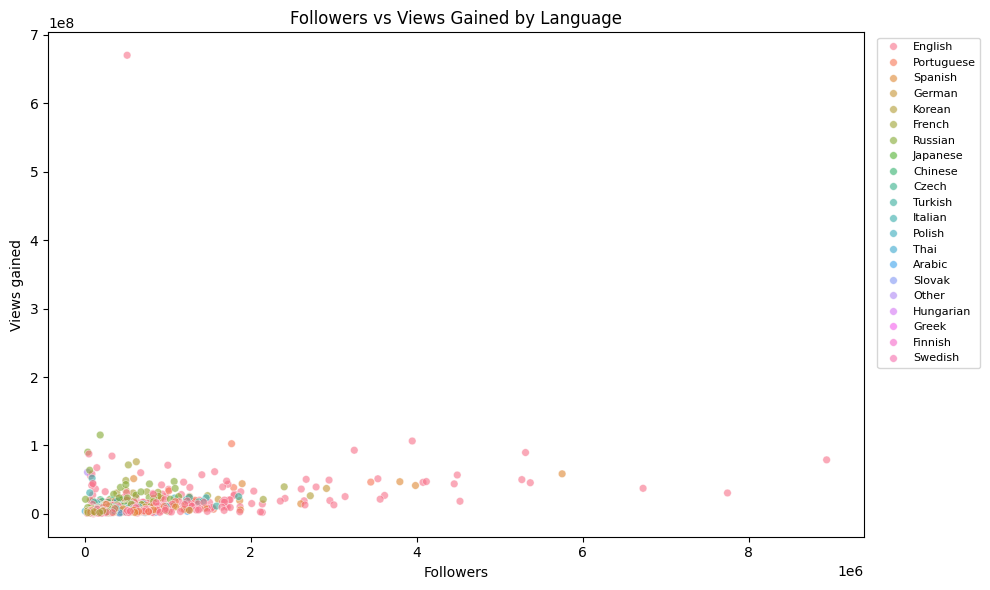

Scatter plot of Followers vs Views Gained. Each dot is a streamer, colored by language. English streamers are spread across the full range while other languages tend to cluster in the lower range.


In [14]:
# color shows how a categorical variable separates numerical data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Followers', y='Views gained', hue='Language', data=df, alpha=0.6, s=30)
plt.title('Followers vs Views Gained by Language')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print("Scatter plot of Followers vs Views Gained. Each dot is a streamer, colored by language. English streamers are spread across the full range while other languages tend to cluster in the lower range.")